In [3]:
# =============================================================================
# CELL 1: Import Required Libraries
# =============================================================================

import os
import pickle
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from tensorflow.keras.utils import to_categorical

from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import train_test_split

print(f"TensorFlow version: {tf.__version__}")
print("Running on CPU (as per project requirements)")
print("✓ Libraries imported successfully")

c:\Users\Putrajaya-PC12\RMK_CONFIDENTIAL\dl-handwriting-recognition\.venv\Lib\site-packages\keras\src\export\tf2onnx_lib.py:8: FutureWarning: In the future `np.object` will be defined as the corresponding NumPy scalar.
  if not hasattr(np, "object"):


TensorFlow version: 2.20.0
Running on CPU (as per project requirements)
✓ Libraries imported successfully


In [4]:
# =============================================================================
# CELL 2: Setup Paths & Load Configuration
# =============================================================================

# Get the base directory (parent of 'notebooks' folder)
BASE_DIR = os.path.dirname(os.getcwd())

# Define paths
PREPROCESSED_DIR = os.path.join(BASE_DIR, 'preprocessed')
MODEL_PATH = os.path.join(BASE_DIR, 'model.keras')

# Load configuration from preprocessing
with open(os.path.join(PREPROCESSED_DIR, 'config.pkl'), 'rb') as f:
    config = pickle.load(f)

PATCH_H = config['PATCH_H']
PATCH_W = config['PATCH_W']
NUM_CHANNELS = 1  # Grayscale patches
NUM_CLASSES = config['NUM_CLASSES']

print("CONFIGURATION LOADED")
print("=" * 60)
print(f"Patch size: {PATCH_W} × {PATCH_H}")
print(f"Channels: {NUM_CHANNELS}")
print(f"Number of classes (writers): {NUM_CLASSES}")
print(f"\nModel will be saved to: {MODEL_PATH}")

CONFIGURATION LOADED
Patch size: 128 × 128
Channels: 1
Number of classes (writers): 70

Model will be saved to: c:\Users\Putrajaya-PC12\RMK_CONFIDENTIAL\dl-handwriting-recognition\model.keras


In [5]:
# =============================================================================
# CELL 3: Load Preprocessed Patch Data
# =============================================================================

print("LOADING PREPROCESSED PATCH DATA")
print("=" * 60)

# Load patch numpy arrays
X_train = np.load(os.path.join(PREPROCESSED_DIR, 'X_train_patches.npy'))
y_train = np.load(os.path.join(PREPROCESSED_DIR, 'y_train_patches.npy'))
X_test = np.load(os.path.join(PREPROCESSED_DIR, 'X_test_patches.npy'))
y_test = np.load(os.path.join(PREPROCESSED_DIR, 'y_test_patches.npy'))

# Load label encoder
with open(os.path.join(PREPROCESSED_DIR, 'label_encoder.pkl'), 'rb') as f:
    label_encoder = pickle.load(f)

# Load test patch map (for aggregation later)
with open(os.path.join(PREPROCESSED_DIR, 'test_patch_map.pkl'), 'rb') as f:
    test_patch_map = pickle.load(f)

with open(os.path.join(PREPROCESSED_DIR, 'test_filenames.pkl'), 'rb') as f:
    test_filenames = pickle.load(f)

print(f"X_train shape: {X_train.shape}  → {X_train.shape[0]} patches")
print(f"y_train shape: {y_train.shape}")
print(f"X_test shape:  {X_test.shape}   → {X_test.shape[0]} patches")
print(f"y_test shape:  {y_test.shape}")
print(f"\nLabel encoder classes: {len(label_encoder.classes_)}")
print(f"Sample classes: {list(label_encoder.classes_[:5])} ... {list(label_encoder.classes_[-5:])}")
print(f"\nTest images (for aggregation): {len(test_patch_map)}")
print("\n✓ Patch data loaded successfully")

LOADING PREPROCESSED PATCH DATA
X_train shape: (13996, 128, 128, 1)  → 13996 patches
y_train shape: (13996,)
X_test shape:  (8852, 128, 128, 1)   → 8852 patches
y_test shape:  (8852,)

Label encoder classes: 70
Sample classes: [np.str_('01'), np.str_('02'), np.str_('03'), np.str_('04'), np.str_('05')] ... [np.str_('66'), np.str_('67'), np.str_('68'), np.str_('69'), np.str_('70')]

Test images (for aggregation): 140

✓ Patch data loaded successfully


In [6]:
# =============================================================================
# CELL 4: Prepare Data for Training
# =============================================================================

print("PREPARING DATA FOR TRAINING")
print("=" * 60)

# Data statistics
print(f"X_train - dtype: {X_train.dtype}, range: [{X_train.min():.3f}, {X_train.max():.3f}]")
print(f"y_train - dtype: {y_train.dtype}, unique values: {len(np.unique(y_train))}")

# Convert labels to one-hot encoding for categorical crossentropy
y_train_cat = to_categorical(y_train, num_classes=NUM_CLASSES)
y_test_cat = to_categorical(y_test, num_classes=NUM_CLASSES)

print(f"\nOne-hot encoded shapes:")
print(f"  y_train_cat: {y_train_cat.shape}")
print(f"  y_test_cat: {y_test_cat.shape}")

# Verify one-hot encoding
print(f"\nOne-hot encoding verification:")
print(f"  Original label: {y_train[0]} (Writer '{label_encoder.inverse_transform([y_train[0]])[0]}')")
print(f"  One-hot vector: {y_train_cat[0][:10]}... (showing first 10 positions)")

# Split some training patches for validation
X_train_split, X_val_split, y_train_split, y_val_split = train_test_split(
    X_train, y_train_cat, test_size=0.15, random_state=42, stratify=y_train
)

print(f"\n✓ Dataset split for training:")
print(f"   Training patches: {X_train_split.shape[0]}")
print(f"   Validation patches: {X_val_split.shape[0]}")
print(f"   Test patches (for final evaluation): {X_test.shape[0]}")

PREPARING DATA FOR TRAINING
X_train - dtype: float32, range: [0.000, 1.000]
y_train - dtype: int64, unique values: 70

One-hot encoded shapes:
  y_train_cat: (13996, 70)
  y_test_cat: (8852, 70)

One-hot encoding verification:
  Original label: 0 (Writer '01')
  One-hot vector: [1. 0. 0. 0. 0. 0. 0. 0. 0. 0.]... (showing first 10 positions)

✓ Dataset split for training:
   Training patches: 11896
   Validation patches: 2100
   Test patches (for final evaluation): 8852


SAMPLE TRAINING PATCHES


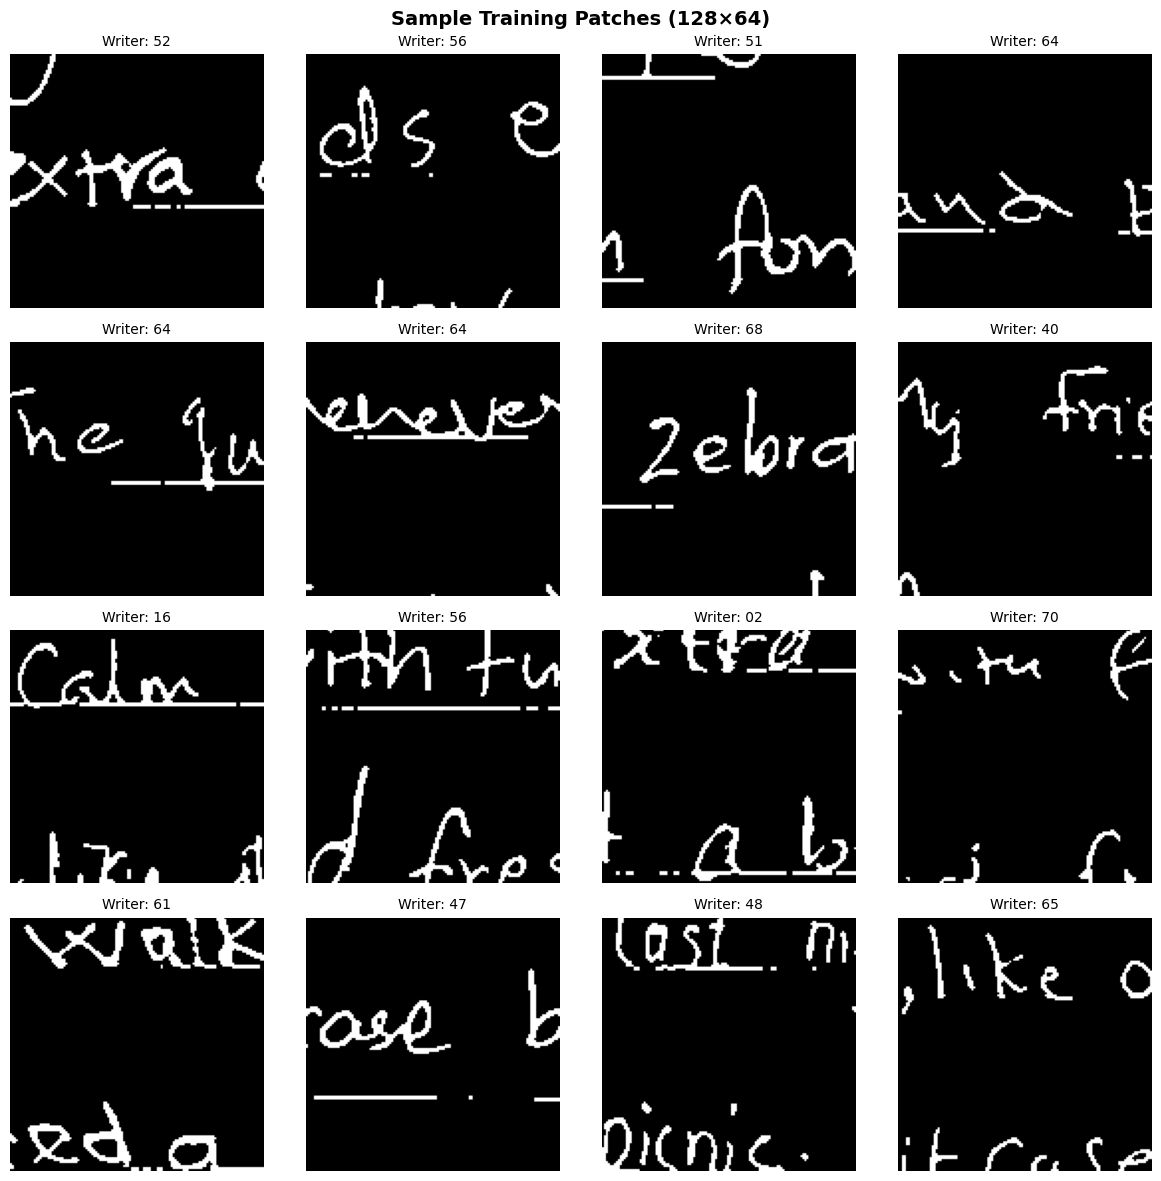

In [7]:
# =============================================================================
# CELL 5: Visualize Sample Patches
# =============================================================================

def visualize_patches(X, y, label_encoder, num_samples=16, title="Sample Patches"):
    """Display a grid of sample patches with their writer IDs"""
    
    # Select random indices
    indices = np.random.choice(len(X), size=min(num_samples, len(X)), replace=False)
    
    # Calculate grid size
    n_cols = 4
    n_rows = (num_samples + n_cols - 1) // n_cols
    
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(12, 3 * n_rows))
    axes = axes.flatten()
    
    for i, idx in enumerate(indices):
        patch = X[idx].squeeze()  # Remove channel dimension for display
        writer_id = label_encoder.inverse_transform([y[idx]])[0]
        
        axes[i].imshow(patch, cmap='gray')
        axes[i].set_title(f'Writer: {writer_id}', fontsize=10)
        axes[i].axis('off')
    
    # Hide empty subplots
    for i in range(len(indices), len(axes)):
        axes[i].axis('off')
    
    plt.suptitle(title, fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

print("SAMPLE TRAINING PATCHES")
print("=" * 60)
visualize_patches(X_train, y_train, label_encoder, num_samples=16, 
                  title="Sample Training Patches (128×64)")

In [8]:
# =============================================================================
# CELL 6: Setup Data Augmentation (IMPROVED - Conservative)
# =============================================================================

print("DATA AUGMENTATION CONFIGURATION (IMPROVED)")
print("=" * 60)

# IMPROVED: Very conservative augmentation for handwriting patches
# Too much augmentation distorts natural writing characteristics
train_datagen = ImageDataGenerator(
    rotation_range=3,            # REDUCED: Minimal rotation
    width_shift_range=0.05,      # REDUCED: Slight horizontal shift
    height_shift_range=0.05,     # REDUCED: Slight vertical shift
    shear_range=0.02,            # REDUCED: Very light shear
    zoom_range=0.03,             # REDUCED: Very light zoom
    fill_mode='constant',        # Fill with background
    cval=0.0                     # Background value (black)
)

print("IMPROVED Augmentation parameters (minimal distortion):")
print("  - Rotation: ±3° (reduced from ±5°)")
print("  - Width shift: ±5% (reduced from ±10%)")
print("  - Height shift: ±5% (reduced from ±10%)")
print("  - Shear: ±2% (reduced from ±5%)")
print("  - Zoom: ±3% (reduced from ±5%)")
print("  - Fill mode: constant (black background)")
print("\nRationale: Handwriting features are sensitive to distortion.")
print("Less augmentation preserves authentic writing characteristics.")
print("\n✓ IMPROVED augmentation configured for patch-based training")

DATA AUGMENTATION CONFIGURATION (IMPROVED)
IMPROVED Augmentation parameters (minimal distortion):
  - Rotation: ±3° (reduced from ±5°)
  - Width shift: ±5% (reduced from ±10%)
  - Height shift: ±5% (reduced from ±10%)
  - Shear: ±2% (reduced from ±5%)
  - Zoom: ±3% (reduced from ±5%)
  - Fill mode: constant (black background)

Rationale: Handwriting features are sensitive to distortion.
Less augmentation preserves authentic writing characteristics.

✓ IMPROVED augmentation configured for patch-based training


In [9]:
# =============================================================================
# CELL 7: Define CNN Model Architecture (IMPROVED)
# =============================================================================

from tensorflow.keras import regularizers

def create_patch_cnn_model(input_shape=(PATCH_H, PATCH_W, NUM_CHANNELS), 
                           num_classes=NUM_CLASSES):
    """
    IMPROVED CNN Model for Writer Identification from Patches
    
    Key improvements:
    1. Larger filter sizes (start with 64 instead of 32)
    2. L2 regularization to prevent overfitting
    3. More capacity in dense layers for 70 classes
    4. Additional pooling adjustment for 128×128 patches
    
    Input: (PATCH_H, PATCH_W, 1) grayscale patches (e.g., 128×128)
    """
    
    # L2 regularization factor
    L2_REG = 0.001
    
    model = keras.Sequential([
        layers.Input(shape=input_shape),
        
        # Block 1: Initial feature extraction
        # For 128×128: 128→64, For 128×64: 128×64→64×32
        layers.Conv2D(64, (3, 3), activation='relu', padding='same',
                     kernel_regularizer=regularizers.l2(L2_REG)),
        layers.BatchNormalization(),
        layers.Conv2D(64, (3, 3), activation='relu', padding='same',
                     kernel_regularizer=regularizers.l2(L2_REG)),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(0.2),  # Reduced from 0.25
        
        # Block 2: Mid-level features
        layers.Conv2D(128, (3, 3), activation='relu', padding='same',
                     kernel_regularizer=regularizers.l2(L2_REG)),
        layers.BatchNormalization(),
        layers.Conv2D(128, (3, 3), activation='relu', padding='same',
                     kernel_regularizer=regularizers.l2(L2_REG)),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(0.2),
        
        # Block 3: Higher-level features
        layers.Conv2D(256, (3, 3), activation='relu', padding='same',
                     kernel_regularizer=regularizers.l2(L2_REG)),
        layers.BatchNormalization(),
        layers.Conv2D(256, (3, 3), activation='relu', padding='same',
                     kernel_regularizer=regularizers.l2(L2_REG)),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(0.25),
        
        # Block 4: Abstract features
        layers.Conv2D(512, (3, 3), activation='relu', padding='same',
                     kernel_regularizer=regularizers.l2(L2_REG)),
        layers.BatchNormalization(),
        layers.Conv2D(512, (3, 3), activation='relu', padding='same',
                     kernel_regularizer=regularizers.l2(L2_REG)),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(0.25),
        
        # Global Average Pooling (spatial dimension agnostic)
        layers.GlobalAveragePooling2D(),
        
        # IMPROVED: Larger dense layers for 70-class discrimination
        layers.Dense(512, activation='relu',
                    kernel_regularizer=regularizers.l2(L2_REG)),
        layers.BatchNormalization(),
        layers.Dropout(0.4),  # Reduced from 0.5
        
        layers.Dense(256, activation='relu',
                    kernel_regularizer=regularizers.l2(L2_REG)),
        layers.BatchNormalization(),
        layers.Dropout(0.4),
        
        # Output layer: 70 writers
        layers.Dense(num_classes, activation='softmax')
    ])
    
    return model

# Create the model
print("IMPROVED MODEL ARCHITECTURE")
print("=" * 60)
print(f"Input shape: ({PATCH_H}, {PATCH_W}, {NUM_CHANNELS})")
print(f"Output classes: {NUM_CLASSES}")
print("\nKey improvements:")
print("  1. Larger initial filters (64 instead of 32)")
print("  2. L2 regularization (factor=0.001)")
print("  3. 4 conv blocks with increasing filters: 64→128→256→512")
print("  4. Larger dense layers: 512→256→70")
print("  5. Reduced dropout (0.2-0.4 instead of 0.25-0.5)")
print("\nBuilding improved patch-based CNN model...\n")

model = create_patch_cnn_model()
model.summary()

# Count parameters
total_params = model.count_params()
print(f"\nTotal parameters: {total_params:,}")
print(f"Estimated model size: {total_params * 4 / (1024**2):.2f} MB (float32)")

IMPROVED MODEL ARCHITECTURE
Input shape: (128, 128, 1)
Output classes: 70

Key improvements:
  1. Larger initial filters (64 instead of 32)
  2. L2 regularization (factor=0.001)
  3. 4 conv blocks with increasing filters: 64→128→256→512
  4. Larger dense layers: 512→256→70
  5. Reduced dropout (0.2-0.4 instead of 0.25-0.5)

Building improved patch-based CNN model...



Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 128, 128, 64)   │           640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128, 128, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 128, 128, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 128, 128, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 64, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64, 64, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 64, 64, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 64, 64, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 64, 64, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 64, 64, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 32, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32, 32, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 32, 32, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 32, 32, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 32, 32, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 32, 32, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 16, 16, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 16, 16, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 16, 16, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 16, 16, 512)    │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 16, 16, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 5,106,950 (19.48 MB)

 Trainable params: 5,101,574 (19.46 MB)

 Non-trainable params: 5,376 (21.00 KB)


Total parameters: 5,106,950
Estimated model size: 19.48 MB (float32)


In [10]:
# =============================================================================
# CELL 8: Compile Model (IMPROVED - Label Smoothing)
# =============================================================================

print("MODEL COMPILATION (IMPROVED)")
print("=" * 60)

# Learning rate
LEARNING_RATE = 0.0005  # Slightly lower for stability with larger model

# IMPROVED: Use label smoothing to prevent overconfident predictions
# This helps with 70-class classification where some classes may be similar
LABEL_SMOOTHING = 0.1

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=LEARNING_RATE),
    loss=keras.losses.CategoricalCrossentropy(label_smoothing=LABEL_SMOOTHING),
    metrics=['accuracy']
)

print(f"Optimizer: Adam")
print(f"  - Learning rate: {LEARNING_RATE} (reduced for stability)")
print(f"  - Will reduce automatically if validation loss plateaus")
print(f"\nLoss function: Categorical Crossentropy with Label Smoothing")
print(f"  - Label smoothing: {LABEL_SMOOTHING}")
print(f"  - Prevents overconfident predictions")
print(f"  - Helps generalization for similar writing styles")
print(f"\nMetrics: Accuracy")
print("\n✓ IMPROVED model compiled with label smoothing")

MODEL COMPILATION (IMPROVED)
Optimizer: Adam
  - Learning rate: 0.0005 (reduced for stability)
  - Will reduce automatically if validation loss plateaus

Loss function: Categorical Crossentropy with Label Smoothing
  - Label smoothing: 0.1
  - Prevents overconfident predictions
  - Helps generalization for similar writing styles

Metrics: Accuracy

✓ IMPROVED model compiled with label smoothing


In [11]:
# =============================================================================
# CELL 9: Configure Training Callbacks (IMPROVED)
# =============================================================================

print("TRAINING CALLBACKS CONFIGURATION (IMPROVED)")
print("=" * 60)

# IMPROVED: Training hyperparameters
BATCH_SIZE = 32          # Smaller batch for better generalization
EPOCHS = 80              # More epochs allowed (early stopping will control)

callbacks = [
    # Stop training if no improvement for 12 epochs (increased patience)
    EarlyStopping(
        monitor='val_accuracy',
        patience=12,
        restore_best_weights=True,
        verbose=1,
        mode='max'
    ),
    
    # Reduce learning rate if validation loss plateaus
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=5,
        min_lr=1e-7,  # Lower floor
        verbose=1
    ),
    
    # Save best model based on validation accuracy
    ModelCheckpoint(
        MODEL_PATH,
        monitor='val_accuracy',
        save_best_only=True,
        verbose=1,
        mode='max'
    )
]

print(f"IMPROVED Training configuration:")
print(f"  - Batch size: {BATCH_SIZE} (smaller for better gradients)")
print(f"  - Max epochs: {EPOCHS} (more epochs allowed)")
print(f"  - Training samples: {X_train_split.shape[0]}")
print(f"  - Steps per epoch: ~{X_train_split.shape[0] // BATCH_SIZE}")
print(f"\nCallbacks configured:")
print(f"  1. EarlyStopping: Stop if val_accuracy doesn't improve for 12 epochs")
print(f"  2. ReduceLROnPlateau: Halve LR if val_loss plateaus for 5 epochs")
print(f"  3. ModelCheckpoint: Save best model to {os.path.basename(MODEL_PATH)}")
print("\n✓ IMPROVED training callbacks ready")

TRAINING CALLBACKS CONFIGURATION (IMPROVED)
IMPROVED Training configuration:
  - Batch size: 32 (smaller for better gradients)
  - Max epochs: 80 (more epochs allowed)
  - Training samples: 11896
  - Steps per epoch: ~371

Callbacks configured:
  1. EarlyStopping: Stop if val_accuracy doesn't improve for 12 epochs
  2. ReduceLROnPlateau: Halve LR if val_loss plateaus for 5 epochs
  3. ModelCheckpoint: Save best model to model.keras

✓ IMPROVED training callbacks ready


In [12]:
# =============================================================================
# CELL 10: Train the Model
# =============================================================================

print("MODEL TRAINING")
print("=" * 60)
print(f"Training on {X_train_split.shape[0]} patches")
print(f"Validating on {X_val_split.shape[0]} patches")
print(f"This may take a while on CPU...\n")

# Create augmented data generator
train_generator = train_datagen.flow(
    X_train_split, 
    y_train_split, 
    batch_size=BATCH_SIZE,
    shuffle=True
)

# Track training time
import time
start_time = time.time()

print(f"Training configuration:")
print(f"  - Batch size: {BATCH_SIZE}")
print(f"  - Max epochs: {EPOCHS}")
print(f"  - Using data augmentation: Yes")
print(f"\nStarting training...\n")

# Train the model
history = model.fit(
    train_generator,
    steps_per_epoch=len(X_train_split) // BATCH_SIZE,
    epochs=EPOCHS,
    validation_data=(X_val_split, y_val_split),
    callbacks=callbacks,
    verbose=1
)

# Calculate training time
training_time = time.time() - start_time
minutes = int(training_time // 60)
seconds = int(training_time % 60)

print("\n" + "=" * 60)
print("TRAINING COMPLETE")
print("=" * 60)
print(f"Total training time: {minutes}m {seconds}s")
print(f"Epochs completed: {len(history.history['loss'])}")
print(f"Best validation accuracy: {max(history.history['val_accuracy']):.4f}")
print(f"\nModel saved to: {MODEL_PATH}")

MODEL TRAINING
Training on 11896 patches
Validating on 2100 patches
This may take a while on CPU...

Training configuration:
  - Batch size: 32
  - Max epochs: 80
  - Using data augmentation: Yes

Starting training...

Epoch 1/80
371/371 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.0448 - loss: 7.0430
Epoch 1: val_accuracy improved from None to 0.02333, saving model to c:\Users\Putrajaya-PC12\RMK_CONFIDENTIAL\dl-handwriting-recognition\model.keras

Epoch 1: finished saving model to c:\Users\Putrajaya-PC12\RMK_CONFIDENTIAL\dl-handwriting-recognition\model.keras
371/371 ━━━━━━━━━━━━━━━━━━━━ 474s 1s/step - accuracy: 0.0807 - loss: 6.5083 - val_accuracy: 0.0233 - val_loss: 11.7176 - learning_rate: 5.0000e-04
Epoch 2/80
  1/371 ━━━━━━━━━━━━━━━━━━━━ 7:29 1s/step - accuracy: 0.2188 - loss: 5.4972

c:\Users\Putrajaya-PC12\RMK_CONFIDENTIAL\dl-handwriting-recognition\.venv\Lib\site-packages\keras\src\trainers\epoch_iterator.py:116: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()



Epoch 2: val_accuracy did not improve from 0.02333
371/371 ━━━━━━━━━━━━━━━━━━━━ 20s 52ms/step - accuracy: 0.2188 - loss: 5.4972 - val_accuracy: 0.0233 - val_loss: 11.7143 - learning_rate: 5.0000e-04
Epoch 3/80
371/371 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.2194 - loss: 5.3562
Epoch 3: val_accuracy improved from 0.02333 to 0.07524, saving model to c:\Users\Putrajaya-PC12\RMK_CONFIDENTIAL\dl-handwriting-recognition\model.keras

Epoch 3: finished saving model to c:\Users\Putrajaya-PC12\RMK_CONFIDENTIAL\dl-handwriting-recognition\model.keras
371/371 ━━━━━━━━━━━━━━━━━━━━ 466s 1s/step - accuracy: 0.2565 - loss: 5.0893 - val_accuracy: 0.0752 - val_loss: 7.5156 - learning_rate: 5.0000e-04
Epoch 4/80
  1/371 ━━━━━━━━━━━━━━━━━━━━ 7:22 1s/step - accuracy: 0.4062 - loss: 4.5195
Epoch 4: val_accuracy improved from 0.07524 to 0.07952, saving model to c:\Users\Putrajaya-PC12\RMK_CONFIDENTIAL\dl-handwriting-recognition\model.keras

Epoch 4: finished saving model to c:\Users\Putrajaya-PC12\RMK_

TRAINING HISTORY VISUALIZATION


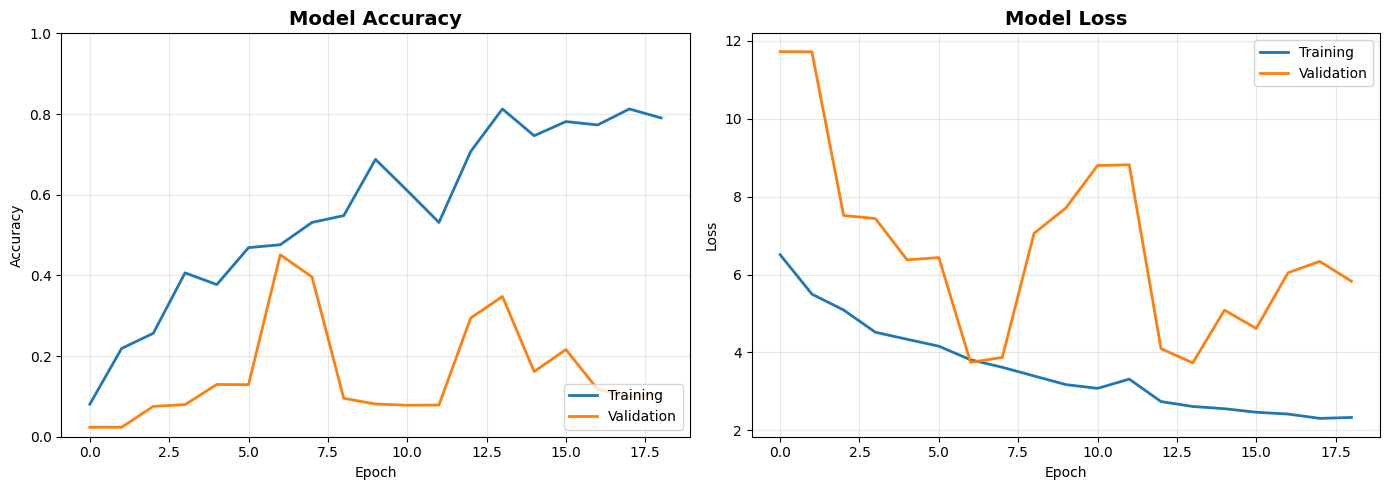


✓ Training history plot saved to: training_history.png


In [13]:
# =============================================================================
# CELL 11: Plot Training History
# =============================================================================

print("TRAINING HISTORY VISUALIZATION")
print("=" * 60)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot accuracy
axes[0].plot(history.history['accuracy'], label='Training', linewidth=2)
axes[0].plot(history.history['val_accuracy'], label='Validation', linewidth=2)
axes[0].set_title('Model Accuracy', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend(loc='lower right')
axes[0].grid(True, alpha=0.3)
axes[0].set_ylim([0, 1])

# Plot loss
axes[1].plot(history.history['loss'], label='Training', linewidth=2)
axes[1].plot(history.history['val_loss'], label='Validation', linewidth=2)
axes[1].set_title('Model Loss', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend(loc='upper right')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(BASE_DIR, 'training_history.png'), dpi=150)
plt.show()

print(f"\n✓ Training history plot saved to: training_history.png")

In [14]:
# =============================================================================
# CELL 12: Evaluate on Validation Patches
# =============================================================================

print("PATCH-LEVEL EVALUATION (Validation Set)")
print("=" * 60)

# Evaluate on validation patches
val_loss, val_accuracy = model.evaluate(X_val_split, y_val_split, verbose=0)
print(f"Validation Loss: {val_loss:.4f}")
print(f"Validation Accuracy: {val_accuracy:.4f}")

# Get predictions
val_predictions = model.predict(X_val_split, verbose=0)
val_pred_classes = np.argmax(val_predictions, axis=1)
val_true_classes = np.argmax(y_val_split, axis=1)

# Classification report (simplified)
print(f"\nCorrect predictions: {np.sum(val_pred_classes == val_true_classes)}/{len(val_true_classes)}")
print(f"Accuracy: {np.mean(val_pred_classes == val_true_classes):.4f}")

PATCH-LEVEL EVALUATION (Validation Set)
Validation Loss: 3.7462
Validation Accuracy: 0.4510

Correct predictions: 947/2100
Accuracy: 0.4510


In [15]:
# =============================================================================
# CELL 13: Image-Level Aggregation Function (IMPROVED)
# =============================================================================

def aggregate_patch_predictions(patch_probs, method='weighted_mean', 
                                 confidence_threshold=0.0, top_k=None):
    """
    IMPROVED: Aggregate patch-level predictions to image-level prediction.
    
    Args:
        patch_probs: (N, num_classes) array of softmax probabilities
        method: 'mean', 'vote', 'weighted_mean', or 'top_k_mean'
        confidence_threshold: Minimum confidence to include a patch (0.0-1.0)
        top_k: For 'top_k_mean', only use top k most confident patches
    
    Returns:
        predicted_class: int
        confidence: float (max probability after aggregation)
        aggregated_probs: (num_classes,) array
    """
    if len(patch_probs) == 0:
        return -1, 0.0, np.zeros(NUM_CLASSES)
    
    # Get confidence (max prob) for each patch
    patch_confidences = np.max(patch_probs, axis=1)
    
    # Filter by confidence threshold if specified
    if confidence_threshold > 0:
        mask = patch_confidences >= confidence_threshold
        if np.sum(mask) > 0:
            patch_probs = patch_probs[mask]
            patch_confidences = patch_confidences[mask]
    
    if len(patch_probs) == 0:
        return -1, 0.0, np.zeros(NUM_CLASSES)
    
    if method == 'mean':
        # Simple average of softmax probabilities
        aggregated_probs = np.mean(patch_probs, axis=0)
        
    elif method == 'vote':
        # Majority voting
        votes = np.argmax(patch_probs, axis=1)
        vote_counts = np.bincount(votes, minlength=NUM_CLASSES)
        aggregated_probs = vote_counts / len(votes)
        
    elif method == 'weighted_mean':
        # IMPROVED: Weight patches by their confidence
        # More confident patches contribute more to the final prediction
        weights = patch_confidences ** 2  # Square for emphasis on high confidence
        weights = weights / np.sum(weights)  # Normalize
        aggregated_probs = np.sum(patch_probs * weights[:, np.newaxis], axis=0)
        
    elif method == 'top_k_mean':
        # IMPROVED: Only use top-k most confident patches
        k = top_k if top_k is not None else min(20, len(patch_probs))
        k = min(k, len(patch_probs))
        top_indices = np.argsort(patch_confidences)[-k:]
        aggregated_probs = np.mean(patch_probs[top_indices], axis=0)
        
    else:
        raise ValueError(f"Unknown method: {method}")
    
    predicted_class = np.argmax(aggregated_probs)
    confidence = aggregated_probs[predicted_class]
    
    return predicted_class, confidence, aggregated_probs

print("✓ IMPROVED Aggregation function defined")
print("\nAggregation methods available:")
print("  - 'mean': Simple average of softmax probabilities")
print("  - 'vote': Majority voting based on patch predictions")
print("  - 'weighted_mean': Confidence-weighted average (RECOMMENDED)")
print("  - 'top_k_mean': Only use top-k most confident patches")
print("\nAdditional options:")
print("  - confidence_threshold: Filter out low-confidence patches")
print("  - top_k: Number of patches for top_k_mean method")

✓ IMPROVED Aggregation function defined

Aggregation methods available:
  - 'mean': Simple average of softmax probabilities
  - 'vote': Majority voting based on patch predictions
  - 'weighted_mean': Confidence-weighted average (RECOMMENDED)
  - 'top_k_mean': Only use top-k most confident patches

Additional options:
  - confidence_threshold: Filter out low-confidence patches
  - top_k: Number of patches for top_k_mean method


In [16]:
# =============================================================================
# CELL 14: Evaluate at Image Level (Test Set) - IMPROVED
# =============================================================================

print("IMAGE-LEVEL EVALUATION (Test Set) - IMPROVED")
print("=" * 60)

# Get predictions for ALL test patches at once
print("Predicting on all test patches...")
all_test_probs = model.predict(X_test, verbose=1)

# IMPROVED: Compare different aggregation methods
aggregation_methods = ['mean', 'weighted_mean', 'top_k_mean', 'vote']
method_results = {}

for agg_method in aggregation_methods:
    image_predictions = []
    image_true_labels = []
    image_confidences = []
    
    for filename in test_filenames:
        start_idx, end_idx = test_patch_map[filename]
        
        # Get true label from filename
        true_writer = filename[:2]
        true_class = label_encoder.transform([true_writer])[0]
        
        if end_idx > start_idx:
            # Get patch probabilities for this image
            patch_probs = all_test_probs[start_idx:end_idx]
            
            # Aggregate using specified method
            top_k = 30 if agg_method == 'top_k_mean' else None
            pred_class, confidence, _ = aggregate_patch_predictions(
                patch_probs, method=agg_method, top_k=top_k
            )
        else:
            pred_class = 0
            confidence = 0.0
        
        image_predictions.append(pred_class)
        image_true_labels.append(true_class)
        image_confidences.append(confidence)
    
    # Calculate accuracy for this method
    correct = np.sum(np.array(image_predictions) == np.array(image_true_labels))
    total = len(image_true_labels)
    accuracy = correct / total
    method_results[agg_method] = {
        'accuracy': accuracy,
        'predictions': image_predictions,
        'confidences': image_confidences
    }

# Print comparison
print("\n" + "=" * 60)
print("AGGREGATION METHOD COMPARISON")
print("=" * 60)
for method, results in method_results.items():
    acc = results['accuracy']
    print(f"  {method:15s}: {acc:.4f} ({acc*100:.2f}%)")

# Use the best method for final results
best_method = max(method_results, key=lambda x: method_results[x]['accuracy'])
print(f"\n→ Best method: {best_method}")

# Store final predictions using best method
image_predictions = np.array(method_results[best_method]['predictions'])
image_true_labels = np.array([label_encoder.transform([fn[:2]])[0] for fn in test_filenames])
image_confidences = method_results[best_method]['confidences']
image_accuracy = method_results[best_method]['accuracy']

print("\n" + "=" * 60)
print("FINAL IMAGE-LEVEL RESULTS")
print("=" * 60)
print(f"Test images: {len(image_true_labels)}")
print(f"Correct predictions: {np.sum(image_predictions == image_true_labels)}")
print(f"Image-level accuracy: {image_accuracy:.4f} ({image_accuracy*100:.2f}%)")
print(f"Average confidence: {np.mean(image_confidences):.4f}")

IMAGE-LEVEL EVALUATION (Test Set) - IMPROVED
Predicting on all test patches...
277/277 ━━━━━━━━━━━━━━━━━━━━ 74s 266ms/step

AGGREGATION METHOD COMPARISON
  mean           : 0.4500 (45.00%)
  weighted_mean  : 0.4357 (43.57%)
  top_k_mean     : 0.4429 (44.29%)
  vote           : 0.4214 (42.14%)

→ Best method: mean

FINAL IMAGE-LEVEL RESULTS
Test images: 140
Correct predictions: 63
Image-level accuracy: 0.4500 (45.00%)
Average confidence: 0.2521


In [17]:
# =============================================================================
# CELL 15: Generate result.csv
# =============================================================================

import pandas as pd

print("GENERATING RESULTS FILE")
print("=" * 60)

# Create results dataframe
results = []
for i, filename in enumerate(test_filenames):
    pred_class = image_predictions[i]
    pred_writer = label_encoder.inverse_transform([pred_class])[0]
    true_writer = filename[:2]
    confidence = image_confidences[i]
    
    results.append({
        'filename': filename,
        'predicted_writer': pred_writer,
        'true_writer': true_writer,
        'correct': pred_writer == true_writer,
        'confidence': confidence
    })

results_df = pd.DataFrame(results)

# Save to CSV
results_path = os.path.join(BASE_DIR, 'result.csv')
results_df.to_csv(results_path, index=False)

print(f"Results saved to: {results_path}")
print(f"\nSample predictions:")
print(results_df.head(10).to_string(index=False))

print(f"\n" + "=" * 60)
print("SUMMARY")
print("=" * 60)
print(f"Total test images: {len(results_df)}")
print(f"Correct: {results_df['correct'].sum()}")
print(f"Accuracy: {results_df['correct'].mean():.4f}")

GENERATING RESULTS FILE
Results saved to: c:\Users\Putrajaya-PC12\RMK_CONFIDENTIAL\dl-handwriting-recognition\result.csv

Sample predictions:
    filename predicted_writer true_writer  correct  confidence
01_2_281.png               57          01    False    0.089820
01_2_491.png               68          01    False    0.142709
02_2_352.png               26          02    False    0.285329
02_2_492.png               02          02     True    0.232819
03_2_353.png               03          03     True    0.172941
03_2_493.png               03          03     True    0.263925
04_2_424.png               04          04     True    0.220548
04_2_494.png               04          04     True    0.204370
05_2_355.png               05          05     True    0.281038
05_2_495.png               05          05     True    0.245518

SUMMARY
Total test images: 140
Correct: 63
Accuracy: 0.4500


CONFUSION MATRIX


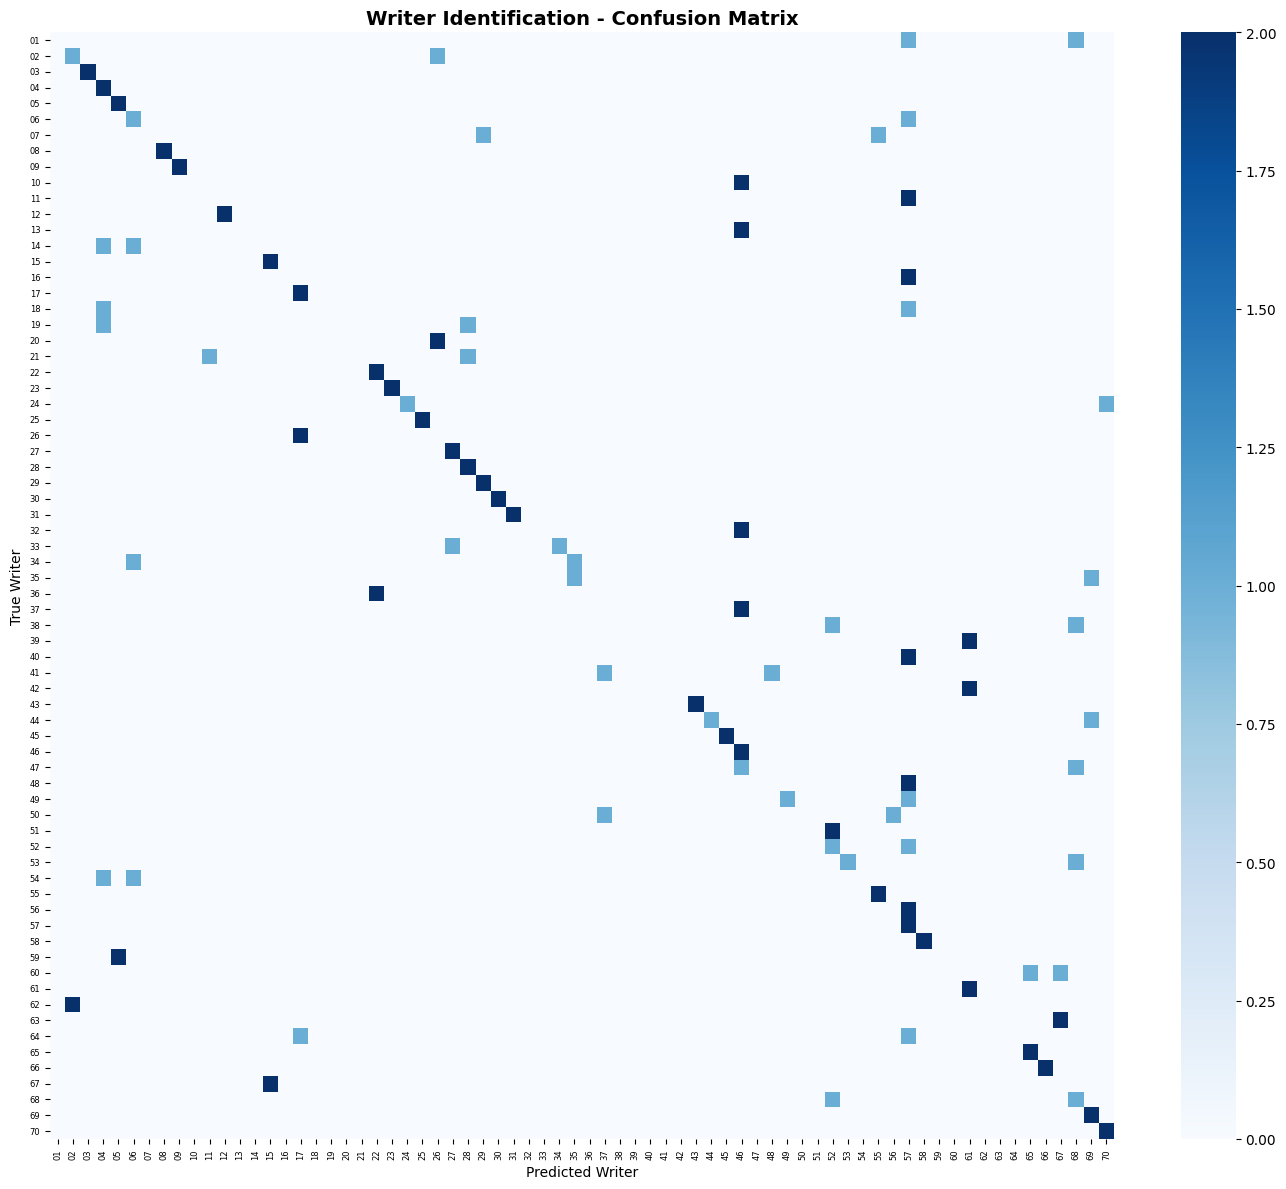


✓ Confusion matrix saved to: confusion_matrix.png

Per-writer accuracy range:
  Min: 0.00% (Writer 01)
  Max: 100.00% (Writer 03)
  Mean: 45.00%


In [18]:
# =============================================================================
# CELL 16: Confusion Matrix (Optional - for analysis)
# =============================================================================

print("CONFUSION MATRIX")
print("=" * 60)

# Compute confusion matrix
cm = confusion_matrix(image_true_labels, image_predictions)

# Plot (condensed for 70 classes)
plt.figure(figsize=(14, 12))
sns.heatmap(cm, cmap='Blues', xticklabels=label_encoder.classes_, 
            yticklabels=label_encoder.classes_, cbar=True)
plt.title('Writer Identification - Confusion Matrix', fontsize=14, fontweight='bold')
plt.xlabel('Predicted Writer')
plt.ylabel('True Writer')
plt.xticks(rotation=90, fontsize=6)
plt.yticks(rotation=0, fontsize=6)
plt.tight_layout()
plt.savefig(os.path.join(BASE_DIR, 'confusion_matrix.png'), dpi=150)
plt.show()

print(f"\n✓ Confusion matrix saved to: confusion_matrix.png")

# Show per-class accuracy
per_class_correct = np.diag(cm)
per_class_total = cm.sum(axis=1)
per_class_acc = per_class_correct / np.maximum(per_class_total, 1)

print(f"\nPer-writer accuracy range:")
print(f"  Min: {per_class_acc.min():.2%} (Writer {label_encoder.classes_[np.argmin(per_class_acc)]})")
print(f"  Max: {per_class_acc.max():.2%} (Writer {label_encoder.classes_[np.argmax(per_class_acc)]})")
print(f"  Mean: {per_class_acc.mean():.2%}")

In [20]:
# =============================================================================
# CELL 17: Final Summary
# =============================================================================

print("=" * 60)
print("TRAINING COMPLETE - FINAL SUMMARY")
print("=" * 60)

print(f"\n📊 Dataset:")
print(f"   Training patches: {X_train.shape[0]}")
print(f"   Test patches: {X_test.shape[0]}")
print(f"   Test images: {len(test_filenames)}")

print(f"\n🧠 Model:")
print(f"   Architecture: Patch-based CNN (128×128 input)")
print(f"   Parameters: {model.count_params():,}")
print(f"   Saved to: {MODEL_PATH}")

print(f"\n📈 Performance:")
print(f"   Best validation accuracy: {max(history.history['val_accuracy']):.4f}")
print(f"   Image-level test accuracy: {image_accuracy:.4f}")

print(f"\n📁 Output files:")
print(f"   - model.keras (trained model)")
print(f"   - result.csv (predictions)")
print(f"   - training_history.png")
print(f"   - confusion_matrix.png")

print("\n✓ Ready for deployment with run.py!")

TRAINING COMPLETE - FINAL SUMMARY

📊 Dataset:
   Training patches: 13996
   Test patches: 8852
   Test images: 140

🧠 Model:
   Architecture: Patch-based CNN (128×128 input)
   Parameters: 5,106,950
   Saved to: c:\Users\Putrajaya-PC12\RMK_CONFIDENTIAL\dl-handwriting-recognition\model.keras

📈 Performance:
   Best validation accuracy: 0.4510
   Image-level test accuracy: 0.4500

📁 Output files:
   - model.keras (trained model)
   - result.csv (predictions)
   - training_history.png
   - confusion_matrix.png

✓ Ready for deployment with run.py!
